### Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

### Load data

In [7]:
df = pd.read_csv("../data/games_march2025_cleaned.csv")
df.shape

(89618, 47)

### Structure Overview

In [8]:
df.dtypes.value_counts()

str        23
int64      19
bool        3
float64     2
Name: count, dtype: int64

### Missing Variables

In [9]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})

,n_missing,pct_missing
score_rank,89579,99.96
metacritic_url,86071,96.04
reviews,79217,88.39
notes,72975,81.43
website,48504,54.12
support_url,45508,50.78
support_email,10820,12.07
about_the_game,220,0.25
detailed_description,197,0.22
short_description,120,0.13


### Drop irrelevant columns

In [10]:
drop_cols = [
    "header_image", "website", "support_url", "support_email",
    "metacritic_url", "screenshots", "movies", "packages",
    "detailed_description", "about_the_game", "short_description",
    "notes", "user_score", "score_rank",
]
df_eda = df.drop(columns=drop_cols)
df_eda.shape

(89618, 33)

### Parse list like string columns

In [11]:
import ast

list_cols = ["genres", "categories", "developers", "publishers",
             "supported_languages", "full_audio_languages", "tags"]

def parse_list_col(x):
    try:
        return ast.literal_eval(x) if pd.notna(x) else []
    except (ValueError, SyntaxError):
        return []

for col in list_cols:
    df_eda[col] = df_eda[col].apply(parse_list_col)

df_eda["n_genres"] = df_eda["genres"].apply(len)

### Pick angle

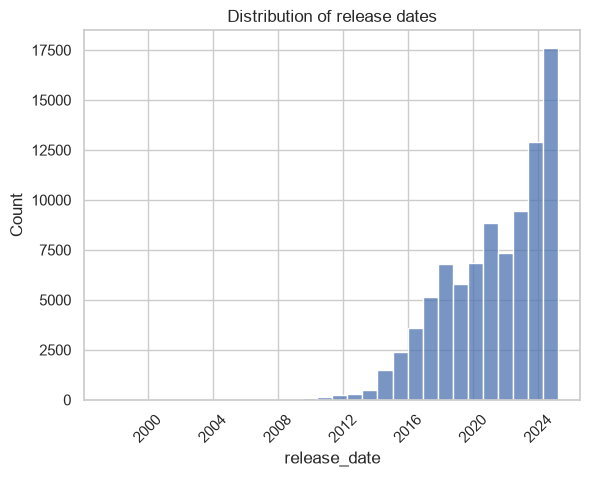

In [12]:
df_eda["release_date"] = pd.to_datetime(df_eda["release_date"], errors="coerce")

sns.histplot(df_eda["release_date"].dropna(), bins=30)
plt.title("Distribution of release dates")
plt.xticks(rotation=45)
plt.show()

### Filter on review count

In [13]:
df_eda["num_reviews_total"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

count    8.961800e+04
mean     1.315490e+03
std      3.542370e+04
min     -1.000000e+00
10%     -1.000000e+00
25%     -1.000000e+00
50%      1.500000e+01
75%      8.100000e+01
90%      5.100000e+02
max      8.632939e+06
Name: num_reviews_total, dtype: float64

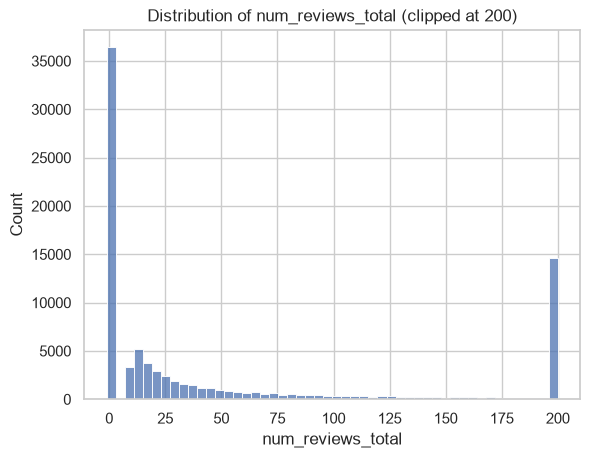

In [14]:
sns.histplot(df_eda["num_reviews_total"].clip(upper=200), bins=50)
plt.title("Distribution of num_reviews_total (clipped at 200)")
plt.show()

In [15]:
MIN_REVIEWS = 30
df_reviewed = df_eda[df_eda["num_reviews_total"] >= MIN_REVIEWS].copy()
print(f"Games kept: {len(df_reviewed)} / {len(df_eda)} ({len(df_reviewed)/len(df_eda)*100:.1f}%)")

Games kept: 34583 / 89618 (38.6%)


### Explode Genres

In [16]:
df_eda["n_genres"].describe()

count    89618.000000
mean         2.879154
std          1.362646
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         19.000000
Name: n_genres, dtype: float64

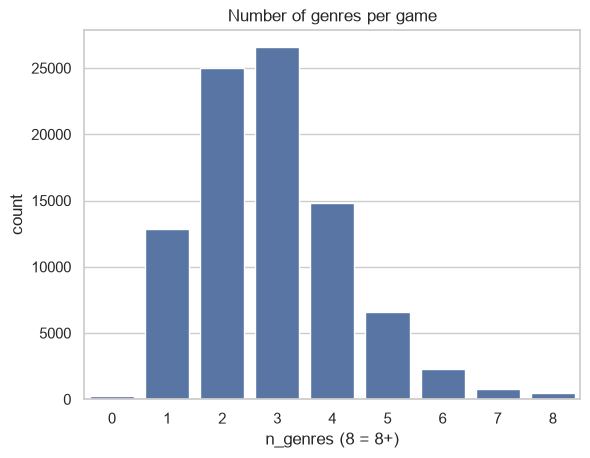

In [17]:
sns.countplot(x=df_eda["n_genres"].clip(upper=8))
plt.title("Number of genres per game")
plt.xlabel("n_genres (8 = 8+)")
plt.show()

In [18]:
df_genre = df_reviewed.explode("genres").rename(columns={"genres": "genre"})
df_genre = df_genre[df_genre["genre"].notna() & (df_genre["genre"] != "")]
df_genre["genre"].nunique()

27

### Genre Distribution

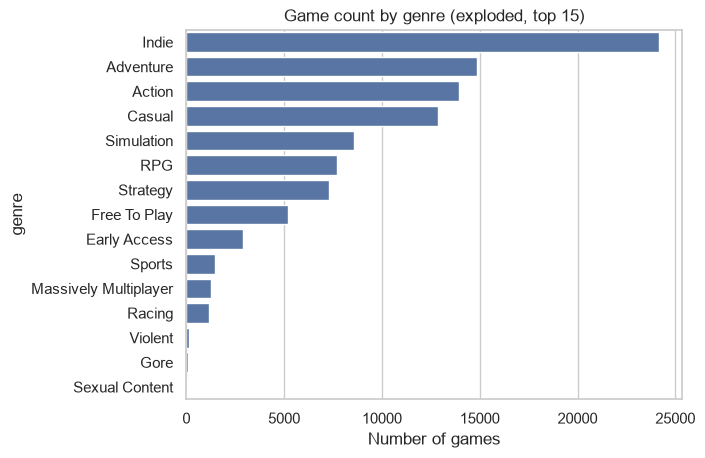

In [19]:
top_genres = df_genre["genre"].value_counts().head(15)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Game count by genre (exploded, top 15)")
plt.xlabel("Number of games")
plt.show()

###  pct_pos_total by genre

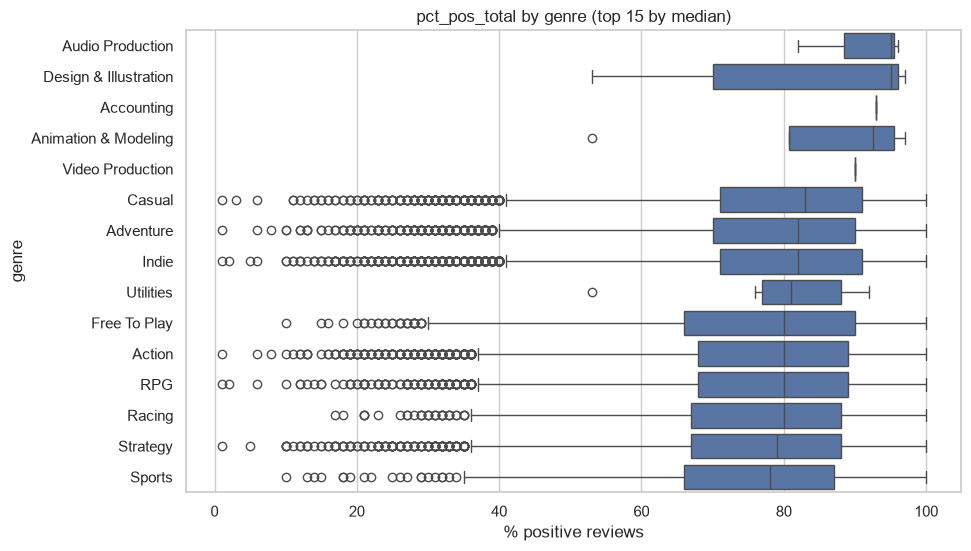

In [20]:
genre_order = df_genre.groupby("genre")["pct_pos_total"].median().sort_values(ascending=False)
top15 = genre_order.head(15).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_genre[df_genre["genre"].isin(top15)],
            x="pct_pos_total", y="genre", order=top15)
plt.title("pct_pos_total by genre (top 15 by median)")
plt.xlabel("% positive reviews")
plt.show()

### Confounders: price and age by genre

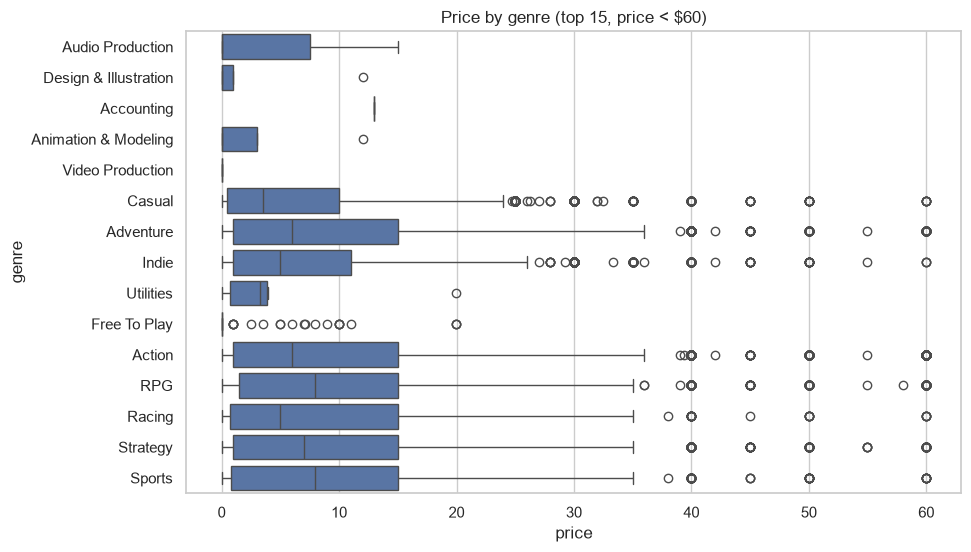

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_genre[df_genre["genre"].isin(top15) & (df_genre["price"] < 60)],
            x="price", y="genre", order=top15)
plt.title("Price by genre (top 15, price < $60)")
plt.show()

In [22]:
age_by_genre = df_genre[df_genre["genre"].isin(top15)].groupby("genre")["required_age"].apply(lambda x: (x > 0).mean())
age_by_genre.sort_values(ascending=False)

genre
Action                   0.039418
RPG                      0.030000
Adventure                0.027216
Strategy                 0.015133
Racing                   0.009624
Free To Play             0.007678
Indie                    0.007535
Sports                   0.005521
Casual                   0.004738
Accounting               0.000000
Animation & Modeling     0.000000
Audio Production         0.000000
Design & Illustration    0.000000
Utilities                0.000000
Video Production         0.000000
Name: required_age, dtype: float64

### Target Missing Variables

In [23]:
cols_of_interest = ["genres", "pct_pos_total", "price", "required_age", "num_reviews_total"]
df_eda[cols_of_interest].isna().sum()

genres               0
pct_pos_total        0
price                0
required_age         0
num_reviews_total    0
dtype: int64